<a href="https://colab.research.google.com/github/Mathildeholst/Speciale/blob/main/Dataanalyse_%C3%A6gte.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
import pandas as pd

uploaded = files.upload()  # Vælg din "Ægte_stemmer.csv" fil
df = pd.read_csv("Ægte_stemmer.csv", encoding="utf-8-sig", sep=";", skiprows=1)
print(f"✅ Indlæst! {df.shape[0]} rækker")
df.head()

Saving Ægte_stemmer.csv to Ægte_stemmer (1).csv
✅ Indlæst! 8088 rækker


,id,created,changed,whisper_guess,tekst,tekst_id,antal_dele,fødselsår,dialekt,køn,postnummer,varighed_sek,lyd_format,har_lydfil
0,456d1b04-f429-4606-972e-3a8e536b5a8c,2024-08-27T16:25:58+00:00,2025-04-22T08:33:00+00:00,Søren cykler hver dag fra sin lejlighed til si...,Søren cykler hver dag fra sin lejlighed til si...,8,11,1950_erne,oestjysk,male,6000.0,54,audio/x-wav,True
1,38488add-5d78-4e66-bc9d-8dcfdb0079ea,2024-08-27T16:25:58+00:00,2025-04-22T08:33:00+00:00,jo bare sådan her. I dag starter Søren sin tur...,I dag starter Søren sin tur ved at tage cyklen...,8,11,1950_erne,oestjysk,male,6000.0,14,audio/x-wav,True
2,659147ab-f913-4107-9819-6b03d987ed80,2024-08-27T16:25:58+00:00,2025-04-22T08:33:00+00:00,Kommunen har gjort meget for at forbedre cykel...,Kommunen har gjort meget for at forbedre cykel...,8,11,1950_erne,oestjysk,male,6000.0,7,audio/x-wav,True
3,4f595695-1b54-4706-b9fc-9e17d07eb1da,2024-08-27T16:25:58+00:00,2025-04-22T08:29:32+00:00,Undervejs baseres søren flere lysbryds med sær...,Undervejs passerer Søren flere lyskryds med sæ...,8,11,1950_erne,oestjysk,male,6000.0,9,audio/x-wav,True
4,b86384e2-0970-4ba3-bb74-f375e95c7cab,2024-08-27T16:25:58+00:00,2025-04-22T08:33:00+00:00,Søren ser også nye skilte for cyklister Skilte...,Søren ser også nye skilte for cyklister. Skilt...,8,11,1950_erne,oestjysk,male,6000.0,8,audio/x-wav,True


In [4]:
print(f"Antal optagelser: {len(df)}")
print(f"Unikke tekster: {df['tekst_id'].nunique()}")
print(f"Unikke dialekter: {df['dialekt'].nunique()}")
print(f"Gennemsnitlig varighed: {df['varighed_sek'].astype(float).mean():.1f} sek")

Antal optagelser: 8088
Unikke tekster: 59
Unikke dialekter: 10
Gennemsnitlig varighed: 12.0 sek


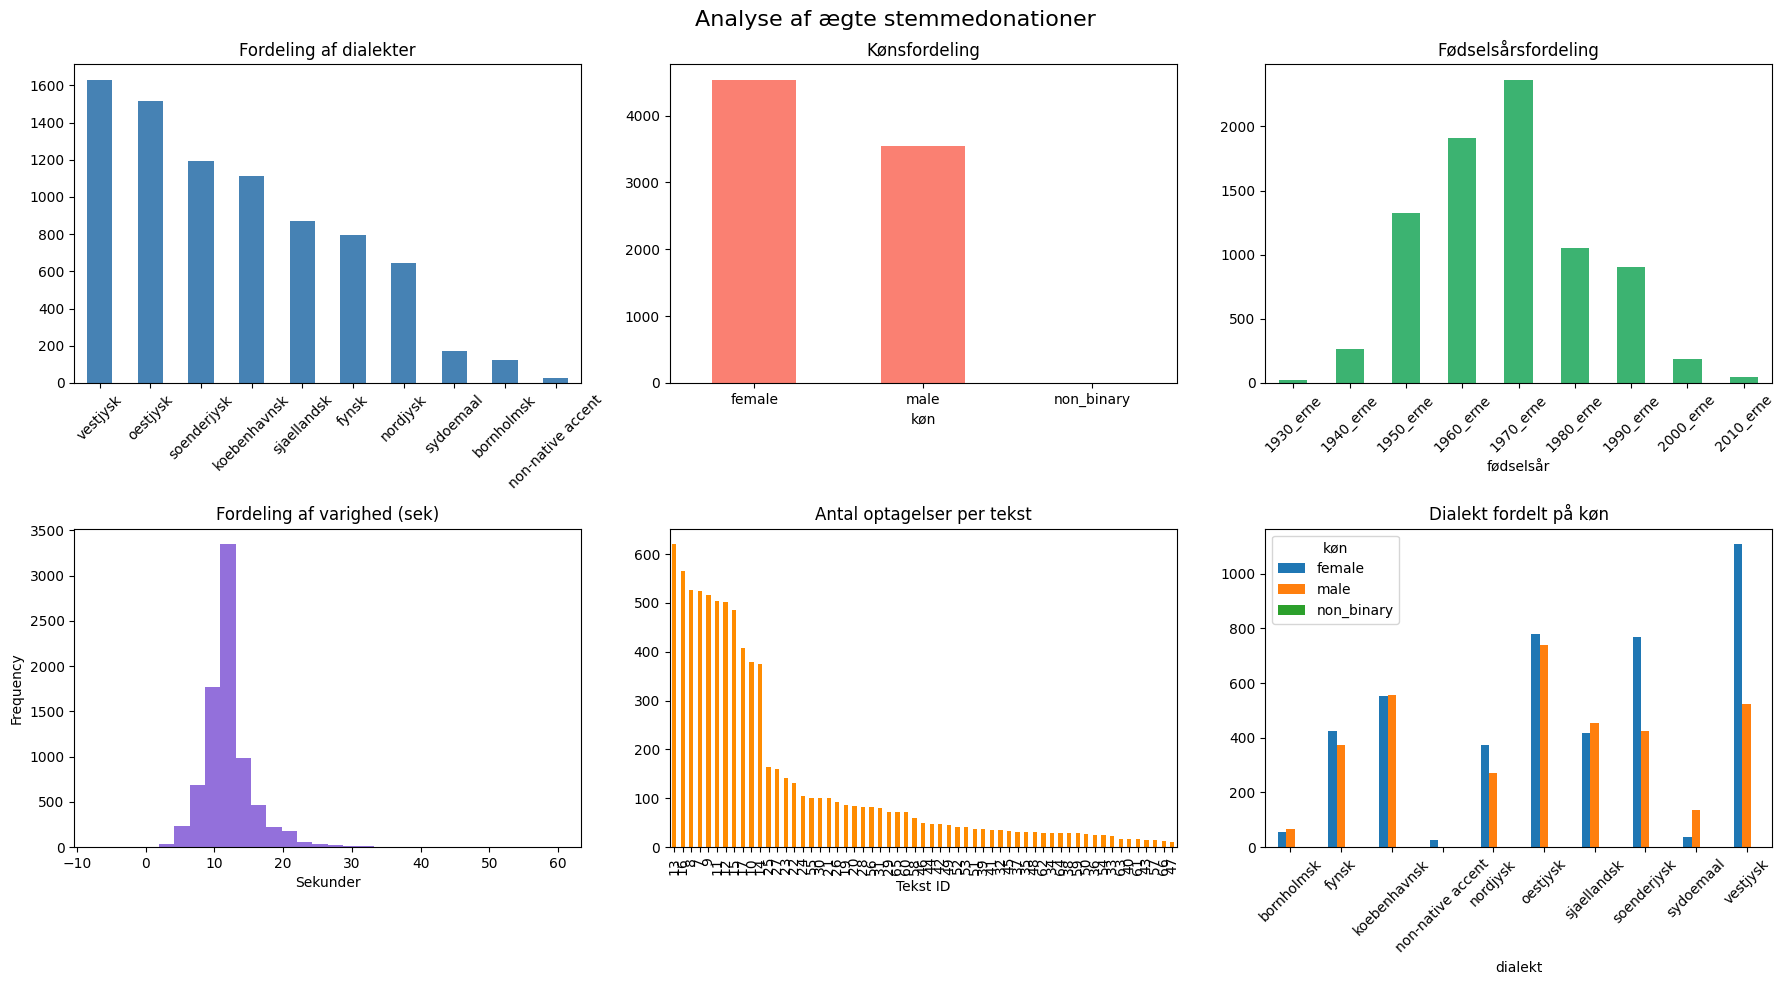

✅ Gemt som analyse.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Analyse af ægte stemmedonationer", fontsize=16)

# Dialekt
df['dialekt'].value_counts().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title("Fordeling af dialekter")
axes[0,0].set_xlabel("")
axes[0,0].tick_params(axis='x', rotation=45)

# Køn
df['køn'].value_counts().plot(kind='bar', ax=axes[0,1], color='salmon')
axes[0,1].set_title("Kønsfordeling")
axes[0,1].tick_params(axis='x', rotation=0)

# Fødselsår
df['fødselsår'].value_counts().sort_index().plot(kind='bar', ax=axes[0,2], color='mediumseagreen')
axes[0,2].set_title("Fødselsårsfordeling")
axes[0,2].tick_params(axis='x', rotation=45)

# Varighed
df['varighed_sek'].astype(float).plot(kind='hist', ax=axes[1,0], bins=30, color='mediumpurple')
axes[1,0].set_title("Fordeling af varighed (sek)")
axes[1,0].set_xlabel("Sekunder")

# Optagelser per tekst
df['tekst_id'].value_counts().plot(kind='bar', ax=axes[1,1], color='darkorange')
axes[1,1].set_title("Antal optagelser per tekst")
axes[1,1].set_xlabel("Tekst ID")

# Dialekt vs køn
df.groupby(['dialekt', 'køn']).size().unstack().plot(kind='bar', ax=axes[1,2])
axes[1,2].set_title("Dialekt fordelt på køn")
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("analyse.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gemt som analyse.png")

In [10]:
tekst_count = df['tekst'].value_counts()
print(f"Antal unikke sætninger: {len(tekst_count)}")
print(f"Mest gentagne sætninger:\n{tekst_count.head(10)}")
print(f"\nSætninger der kun optræder én gang: {(tekst_count == 1).sum()}")

Antal unikke sætninger: 649
Mest gentagne sætninger:
tekst
Maria arbejder i Vildby Kommunes afdeling for Teknik og Miljø. Hver dag bidrager hun til at gøre byen mere bæredygtig. Hun fokuserer på at gøre Vildby grønnere og mere miljøvenlig.    61
Mette arbejder i Vildby Kommunes naturafdeling. Hun har ansvar for at vedligeholde byens parker og skove, så de er flotte og indbydende for alle borgere.                               60
Thomas arbejder i Vildby Kommunes afdeling for affald og genbrug. Hans dag starter tidligt, da han møder ind for at koordinere dagens affaldsindsamling i byen.                         59
Det er aften, og byrådssalen er fyldt med politikere, embedsmænd og borgere. Byrådet i Vildby holder møde for at diskutere vigtige sager, der vedrører byens udvikling.                 58
Kommunen har implementeret et omfattende affaldssorteringssystem. Thomas overvåger indsatsen og sørger for, at skraldebilerne følger ruterne og afhenter affaldet regelmæssigt.         58
Hver d

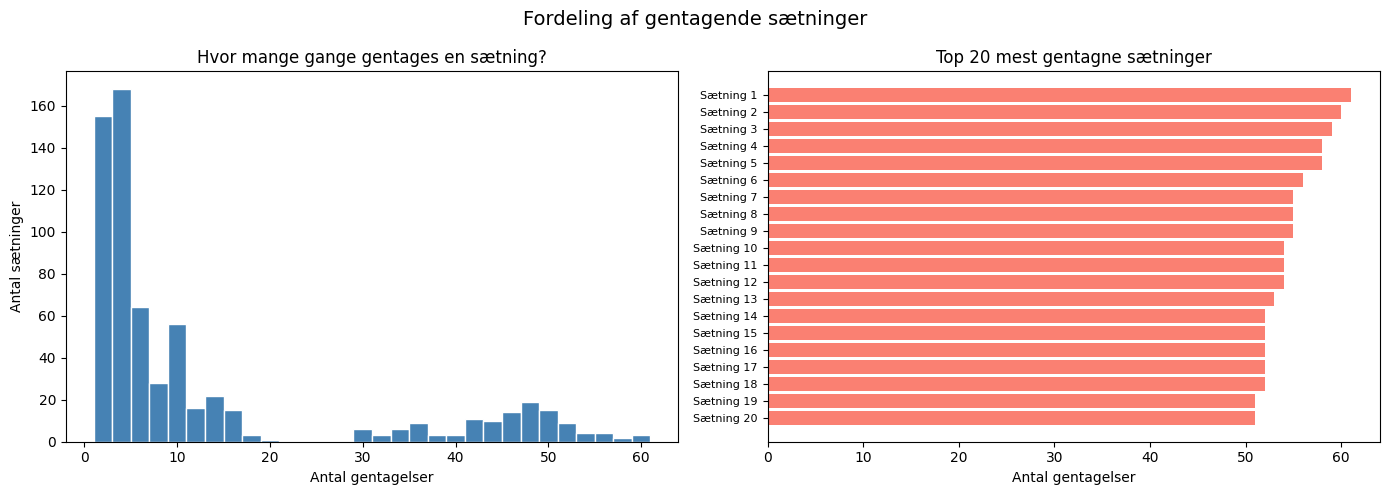


Top 5 mest gentagne sætninger:

(61x): Maria arbejder i Vildby Kommunes afdeling for Teknik og Miljø. Hver dag bidrager hun til at gøre bye...

(60x): Mette arbejder i Vildby Kommunes naturafdeling. Hun har ansvar for at vedligeholde byens parker og s...

(59x): Thomas arbejder i Vildby Kommunes afdeling for affald og genbrug. Hans dag starter tidligt, da han m...

(58x): Det er aften, og byrådssalen er fyldt med politikere, embedsmænd og borgere. Byrådet i Vildby holder...

(58x): Kommunen har implementeret et omfattende affaldssorteringssystem. Thomas overvåger indsatsen og sørg...


In [11]:
import matplotlib.pyplot as plt

tekst_count = df['tekst'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Fordeling af gentagende sætninger", fontsize=14)

# Histogram over hvor mange gange sætninger gentages
axes[0].hist(tekst_count.values, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title("Hvor mange gange gentages en sætning?")
axes[0].set_xlabel("Antal gentagelser")
axes[0].set_ylabel("Antal sætninger")

# Top 20 mest gentagne sætninger
top20 = tekst_count.head(20)
axes[1].barh(range(20), top20.values, color='salmon')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([f"Sætning {i+1}" for i in range(20)], fontsize=8)
axes[1].set_title("Top 20 mest gentagne sætninger")
axes[1].set_xlabel("Antal gentagelser")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nTop 5 mest gentagne sætninger:")
for tekst, antal in tekst_count.head(5).items():
    print(f"\n({antal}x): {tekst[:100]}...")

In [12]:
# Se om antal_dele afslører at samme person har flere optagelser
print(df['antal_dele'].value_counts())

# Tjek om samme bruger optræder flere gange
# (hvis user kolonnen findes)
if 'user' in df.columns:
    print(f"\nUnikke brugere: {df['user'].nunique()}")
    print(f"Optagelser per bruger:\n{df['user'].value_counts().describe()}")

antal_dele
11    4634
10    1502
12     882
9      281
8      215
15     166
16     147
14     136
13      95
7       30
Name: count, dtype: int64


In [13]:
if 'user' in df.columns:
    print(f"Unikke brugere: {df['user'].nunique()}")
    print(f"\nOptagelser per bruger:")
    print(df['user'].value_counts().describe())
else:
    print("Kolonner:", df.columns.tolist())
    print("\nIngen 'user' kolonne - tjek hvad der kan identificere en person")

Kolonner: ['id', 'created', 'changed', 'whisper_guess', 'tekst', 'tekst_id', 'antal_dele', 'fødselsår', 'dialekt', 'køn', 'postnummer', 'varighed_sek', 'lyd_format', 'har_lydfil']

Ingen 'user' kolonne - tjek hvad der kan identificere en person


In [14]:
# Hvor mange unikke sætninger er der per person?
print(f"Unikke sætninger: {df['tekst'].nunique()}")
print(f"Unikke tekst_id: {df['tekst_id'].nunique()}")

# Hvor mange sætninger deler to personer?
sætninger_per_tekst_id = df.groupby('tekst_id')['tekst'].nunique()
print(f"\nUnikke sætninger per tekst_id:\n{sætninger_per_tekst_id.describe()}")

Unikke sætninger: 649
Unikke tekst_id: 59

Unikke sætninger per tekst_id:
count    59.000000
mean     11.000000
std       2.311888
min       5.000000
25%      10.000000
50%      11.000000
75%      12.000000
max      16.000000
Name: tekst, dtype: float64
